# Final Model Comparison
## Medical Insurance Charges Prediction

### Objective
The objective of this notebook is to compare the final optimized results of the six regression models developed by the group.

The models compared are:

1. Linear Regression
2. Ridge Regression
3. Support Vector Regression (SVR)
4. Decision Tree Regressor
5. Random Forest Regressor
6. K-Nearest Neighbors (KNN) Regressor

All models are compared using MAE, RMSE, R², and five-fold cross-validation RMSE.

Lower MAE and RMSE values indicate lower prediction error, while a higher R² value indicates that the model explains more variation in medical insurance charges.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
candidate_roots = [
    Path("."),
    Path("..")
]

project_root = None

for root in candidate_roots:

    result_folder = (
        root
        / "results"
        / "model_results"
    )

    if result_folder.exists():
        project_root = root
        break


if project_root is None:
    raise FileNotFoundError(
        "results/model_results folder was not found."
    )


RESULT_PATH = (
    project_root
    / "results"
    / "model_results"
)

FIGURE_PATH = (
    project_root
    / "results"
    / "model_visualizations"
)

FINAL_RESULT_PATH = (
    project_root
    / "results"
)


FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)


print("Project Root :", project_root)
print("Result Path  :", RESULT_PATH)
print("Figure Path  :", FIGURE_PATH)

Project Root : .
Result Path  : results\model_results
Figure Path  : results\model_visualizations


In [3]:
model_files = {
    "Linear Regression":
        "linear_best.csv",

    "Ridge Regression":
        "ridge_best.csv",

    "Support Vector Regression":
        "svr_best.csv",

    "Decision Tree Regressor":
        "decision_tree_best.csv",

    "Random Forest Regressor":
        "random_forest_best.csv",

    "K-Nearest Neighbors Regressor":
        "knn_best.csv"
}


print("Checking model result files...\n")


all_files_found = True


for model_name, filename in model_files.items():

    file_path = (
        RESULT_PATH
        / filename
    )

    if file_path.exists():

        print(
            f"FOUND   : {model_name}"
        )

    else:

        print(
            f"MISSING : {model_name} -> {filename}"
        )

        all_files_found = False


if not all_files_found:

    raise FileNotFoundError(
        "One or more model result files are missing. "
        "Run the corresponding member notebooks first."
    )


print(
    "\nAll six model result files were found successfully."
)

Checking model result files...

FOUND   : Linear Regression
FOUND   : Ridge Regression
FOUND   : Support Vector Regression
FOUND   : Decision Tree Regressor
FOUND   : Random Forest Regressor
FOUND   : K-Nearest Neighbors Regressor

All six model result files were found successfully.


In [4]:
dataframes = []


for model_name, filename in model_files.items():

    file_path = (
        RESULT_PATH
        / filename
    )

    df = pd.read_csv(
        file_path
    )


    required_columns = [
        "Model",
        "Best_Configuration",
        "MAE",
        "RMSE",
        "R2",
        "CV_RMSE"
    ]


    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]


    if missing_columns:

        raise ValueError(
            f"{filename} is missing columns: "
            f"{missing_columns}"
        )


    dataframes.append(
        df[required_columns]
    )


comparison = pd.concat(
    dataframes,
    ignore_index=True
)


print(
    "Final Model Comparison:"
)

display(
    comparison
)

Final Model Comparison:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,Linear Regression,Linear Regression - All Features,4194.484960,5978.241481,0.805506,6123.287236
1,Ridge Regression,alpha=1,4212.544883,5993.105048,0.804538,6121.690585
2,Support Vector Regression,"{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale', ...",4169.139793,8338.431767,0.621621,7380.189481
3,Decision Tree Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",2600.306097,4353.481923,0.896859,4823.410895
4,Random Forest Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",2415.011356,4254.580654,0.901492,4619.761959
5,K-Nearest Neighbors Regressor,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",3816.304563,6923.019593,0.739175,6644.775115


In [5]:
rmse_comparison = (
    comparison
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


print(
    "Models Ordered by Test RMSE:"
)

display(
    rmse_comparison[
        [
            "Model",
            "RMSE",
            "MAE",
            "R2",
            "CV_RMSE"
        ]
    ]
)

Models Ordered by Test RMSE:


,Model,RMSE,MAE,R2,CV_RMSE
0,Random Forest Regressor,4254.580654,2415.011356,0.901492,4619.761959
1,Decision Tree Regressor,4353.481923,2600.306097,0.896859,4823.410895
2,Linear Regression,5978.241481,4194.484960,0.805506,6123.287236
3,Ridge Regression,5993.105048,4212.544883,0.804538,6121.690585
4,K-Nearest Neighbors Regressor,6923.019593,3816.304563,0.739175,6644.775115
5,Support Vector Regression,8338.431767,4169.139793,0.621621,7380.189481


## Comparison Criteria

The six models are compared using the same main regression evaluation metrics.

- **MAE:** Represents the average absolute prediction error.
- **RMSE:** Measures prediction error while penalizing larger errors more strongly.
- **R²:** Measures the proportion of variation in insurance charges explained by the model.
- **CV RMSE:** Represents average validation error across five cross-validation folds and helps examine how consistently the model performs on different training subsets.

The test-set metrics describe performance on the held-out test observations, while cross-validation results provide additional evidence about model stability during training and validation.

The comparison should consider all metrics together rather than relying on only one value.

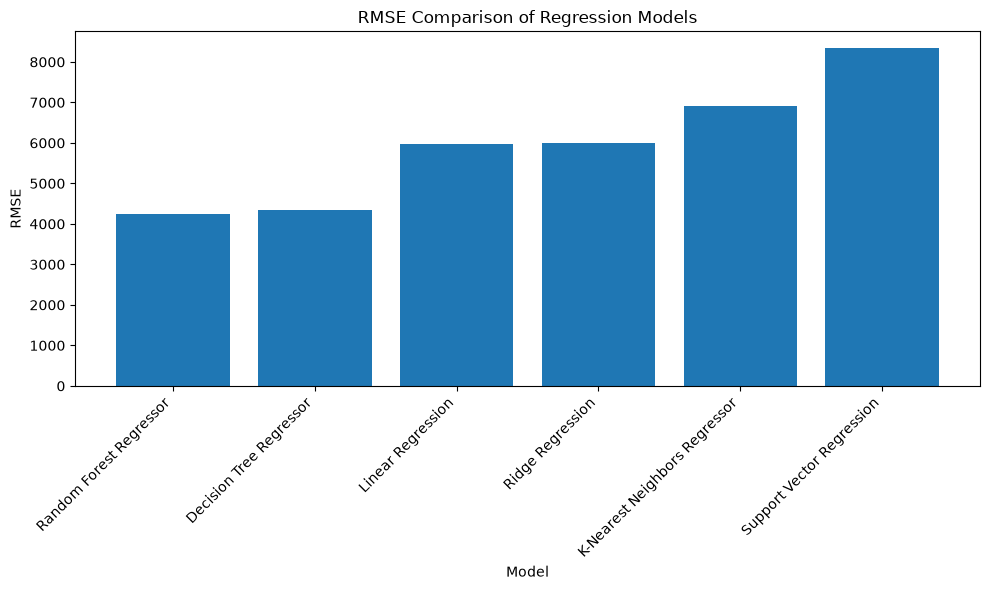

In [6]:
plot_data = (
    comparison
    .sort_values(
        "RMSE",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_data["Model"],
    plot_data["RMSE"]
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "RMSE"
)

plt.title(
    "RMSE Comparison of Regression Models"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "final_rmse_comparison.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()

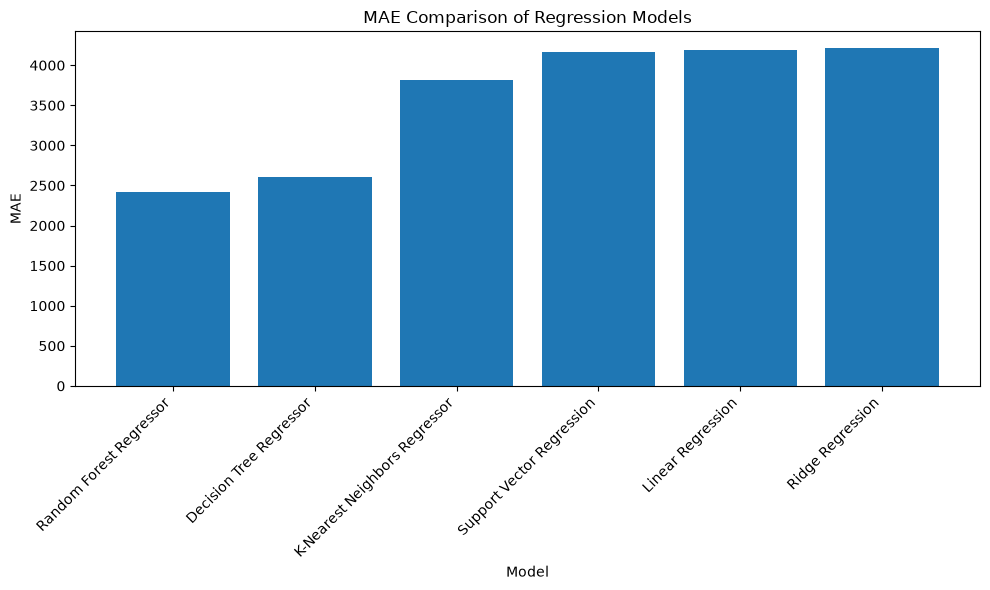

In [7]:
plot_data = (
    comparison
    .sort_values(
        "MAE",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_data["Model"],
    plot_data["MAE"]
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "MAE Comparison of Regression Models"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "final_mae_comparison.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()

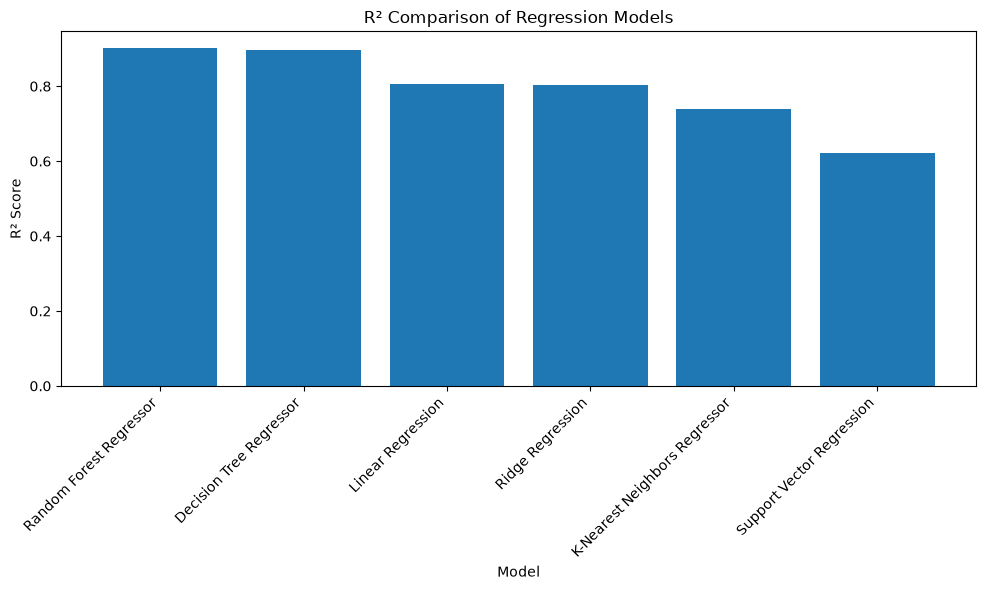

In [8]:
plot_data = (
    comparison
    .sort_values(
        "R2",
        ascending=False
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_data["Model"],
    plot_data["R2"]
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "R² Comparison of Regression Models"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "final_r2_comparison.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()

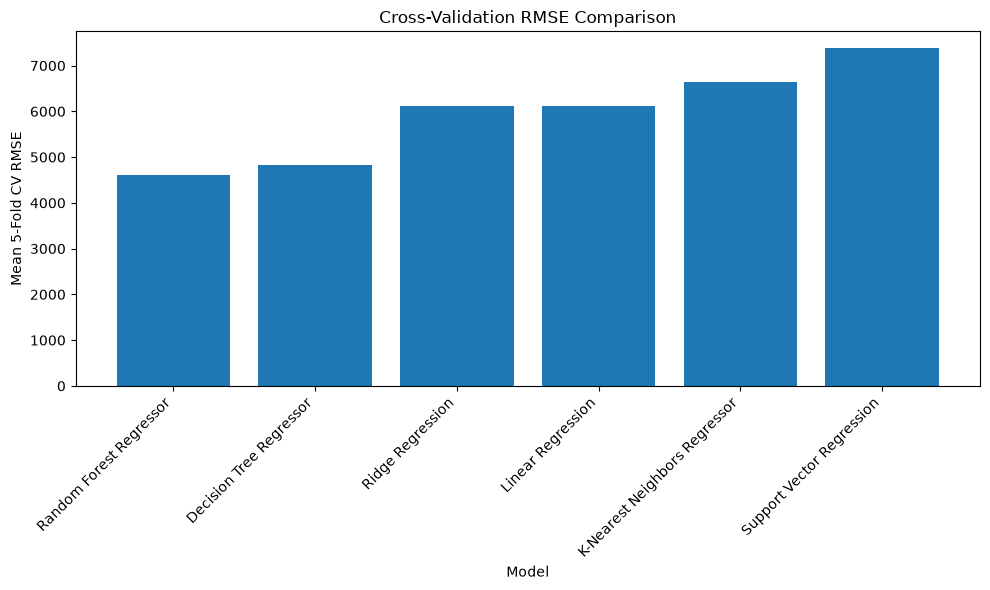

In [9]:
plot_data = (
    comparison
    .sort_values(
        "CV_RMSE",
        ascending=True
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_data["Model"],
    plot_data["CV_RMSE"]
)


plt.xlabel(
    "Model"
)

plt.ylabel(
    "Mean 5-Fold CV RMSE"
)

plt.title(
    "Cross-Validation RMSE Comparison"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "final_cv_rmse_comparison.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [10]:
lowest_rmse_row = (
    comparison.loc[
        comparison["RMSE"].idxmin()
    ]
)

lowest_mae_row = (
    comparison.loc[
        comparison["MAE"].idxmin()
    ]
)

highest_r2_row = (
    comparison.loc[
        comparison["R2"].idxmax()
    ]
)

lowest_cv_rmse_row = (
    comparison.loc[
        comparison["CV_RMSE"].idxmin()
    ]
)


print("Observed Comparison Summary")
print("-" * 60)


print(
    "Lowest Test RMSE:",
    lowest_rmse_row["Model"],
    f"({lowest_rmse_row['RMSE']:.4f})"
)


print(
    "Lowest Test MAE:",
    lowest_mae_row["Model"],
    f"({lowest_mae_row['MAE']:.4f})"
)


print(
    "Highest Test R²:",
    highest_r2_row["Model"],
    f"({highest_r2_row['R2']:.4f})"
)


print(
    "Lowest Mean CV RMSE:",
    lowest_cv_rmse_row["Model"],
    f"({lowest_cv_rmse_row['CV_RMSE']:.4f})"
)

Observed Comparison Summary
------------------------------------------------------------
Lowest Test RMSE: Random Forest Regressor (4254.5807)
Lowest Test MAE: Random Forest Regressor (2415.0114)
Highest Test R²: Random Forest Regressor (0.9015)
Lowest Mean CV RMSE: Random Forest Regressor (4619.7620)


In [11]:
comparison_analysis = (
    comparison.copy()
)


comparison_analysis[
    "Test_CV_RMSE_Difference"
] = abs(
    comparison_analysis["RMSE"]
    - comparison_analysis["CV_RMSE"]
)


comparison_analysis = (
    comparison_analysis
    .sort_values(
        "Test_CV_RMSE_Difference",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


print(
    "Test RMSE vs Cross-Validation RMSE:"
)


display(
    comparison_analysis[
        [
            "Model",
            "RMSE",
            "CV_RMSE",
            "Test_CV_RMSE_Difference"
        ]
    ]
)

Test RMSE vs Cross-Validation RMSE:


,Model,RMSE,CV_RMSE,Test_CV_RMSE_Difference
0,Ridge Regression,5993.105048,6121.690585,128.585537
1,Linear Regression,5978.241481,6123.287236,145.045756
2,K-Nearest Neighbors Regressor,6923.019593,6644.775115,278.244478
3,Random Forest Regressor,4254.580654,4619.761959,365.181305
4,Decision Tree Regressor,4353.481923,4823.410895,469.928972
5,Support Vector Regression,8338.431767,7380.189481,958.242286


In [12]:
configuration_table = (
    comparison[
        [
            "Model",
            "Best_Configuration"
        ]
    ]
    .copy()
)


print(
    "Selected Configuration of Each Model:"
)


display(
    configuration_table
)

Selected Configuration of Each Model:


,Model,Best_Configuration
0,Linear Regression,Linear Regression - All Features
1,Ridge Regression,alpha=1
2,Support Vector Regression,"{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale', ..."
3,Decision Tree Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s..."
4,Random Forest Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s..."
5,K-Nearest Neighbors Regressor,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}"


In [13]:
final_comparison = (
    comparison
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


final_comparison.to_csv(
    FINAL_RESULT_PATH
    / "final_model_comparison.csv",

    index=False
)


comparison_analysis.to_csv(
    FINAL_RESULT_PATH
    / "final_model_stability_comparison.csv",

    index=False
)


print(
    "Final comparison saved successfully."
)


print(
    "\nSaved:",
    FINAL_RESULT_PATH
    / "final_model_comparison.csv"
)


print(
    "Saved:",
    FINAL_RESULT_PATH
    / "final_model_stability_comparison.csv"
)


print(
    "\nFinal Comparison:"
)

display(
    final_comparison
)

Final comparison saved successfully.

Saved: results\final_model_comparison.csv
Saved: results\final_model_stability_comparison.csv

Final Comparison:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,Random Forest Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",2415.011356,4254.580654,0.901492,4619.761959
1,Decision Tree Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",2600.306097,4353.481923,0.896859,4823.410895
2,Linear Regression,Linear Regression - All Features,4194.484960,5978.241481,0.805506,6123.287236
3,Ridge Regression,alpha=1,4212.544883,5993.105048,0.804538,6121.690585
4,K-Nearest Neighbors Regressor,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",3816.304563,6923.019593,0.739175,6644.775115
5,Support Vector Regression,"{'C': 1000, 'epsilon': 0.1, 'gamma': 'scale', ...",4169.139793,8338.431767,0.621621,7380.189481


## Final Comparison and Discussion

Six regression approaches were evaluated for medical insurance charge prediction: Linear Regression, Ridge Regression, Support Vector Regression, Decision Tree Regression, Random Forest Regression, and K-Nearest Neighbors Regression.

The models were evaluated using the same main regression metrics: MAE, RMSE, R², and five-fold cross-validation RMSE. Their selected configurations were obtained from the individual model development and tuning stages.

The final comparison examines:

- prediction error using MAE and RMSE,
- explained variation using R²,
- validation performance using five-fold cross-validation RMSE,
- differences between test and cross-validation performance,
- and the characteristics and limitations of the different model types.

Linear models provide relatively simple and interpretable relationships, while SVR can capture nonlinear patterns through kernel functions. Decision Tree models provide rule-based nonlinear predictions, Random Forest combines multiple trees to improve stability, and KNN predicts charges based on similar observations.

The observed metric values should be interpreted together. A lower error on one metric alone does not provide a complete description of model behavior. Cross-validation results and differences between validation and held-out test performance should also be considered when discussing model consistency and generalization.

### Group-Level Limitations
- The dataset is relatively limited in size and number of features.
- Model performance depends on the available insurance attributes.
- Some potentially relevant medical, lifestyle, and socioeconomic variables are not represented.
- Performance observed on this dataset may not directly generalize to other populations or insurance systems.
- Hyperparameter search spaces are limited to the configurations evaluated in this project.

### Possible Improvements
- Collect a larger and more diverse dataset.
- Investigate additional meaningful features and interaction terms.
- Expand or refine hyperparameter search spaces.
- Use additional validation strategies to examine model stability.
- Evaluate model behavior across relevant subgroups when appropriate.